In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/yahye-abdiweli/personal-finance-analysis/main/data/transactions_2025_26.csv"
df = pd.read_csv(url)

print(df.shape)
df.head(10)

(543, 6)


,Date,Description,Category,Amount,Type,Payment_Method
0,01/10/2025,McDonald's,Eating Out,6.05,Debit,Card
1,01/10/2025,TfL Travel,Transport,1.75,Debit,Contactless
2,01/10/2025,The Gym Group,Health & Fitness,24.99,Debit,Direct Debit
3,01/10/2025,Student Finance England,Income,3300,Credit,Bank Transfer
4,02/10/2025,TfL Travel,Transport,5.25,Debit,Contactless
5,02/10/2025,JD Sports,Shopping,46.89,Debit,Card
6,02/10/2025,Transfer to parents,Household,120,Debit,Bank Transfer
7,03/10/2025,TfL Travel,Transport,3.5,Debit,Contactless
8,03/10/2025,Amazon,Education,6.84,Debit,Card
9,03/10/2025,Part-time job wages,Income,146.52,Credit,Bank Transfer


In [2]:
print("--- Column types ---")
print(df.dtypes)

print("\n--- Missing values per column ---")
print(df.isna().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Category labels ---")
print(df["Category"].value_counts())

--- Column types ---
Date              object
Description       object
Category          object
Amount            object
Type              object
Payment_Method    object
dtype: object

--- Missing values per column ---
Date               0
Description        0
Category          12
Amount             4
Type               0
Payment_Method     0
dtype: int64

--- Duplicate rows ---
8

--- Category labels ---
Category
Eating Out           142
Groceries            121
Transport            116
Subscriptions         31
Income                29
Shopping              20
Entertainment         12
Household             12
Bills                 12
Health & Fitness      11
Education              8
Eating Out             4
Gifts                  3
eating out             2
Entertainment          1
Transport              1
subscriptions          1
SUBSCRIPTIONS          1
Health & Fitness       1
entertainment          1
transport              1
ENTERTAINMENT          1
Name: count, dtype: int64


In [3]:
clean = df.copy()

# 1. Remove duplicate rows
clean = clean.drop_duplicates()

# 2. Standardise category labels (remove extra spaces, consistent capitals)
clean["Category"] = clean["Category"].str.strip().str.title()

# 3. Fill missing categories using the most common category for that merchant
lookup = (clean.dropna(subset=["Category"])
               .groupby("Description")["Category"]
               .agg(lambda s: s.mode()[0]))
clean["Category"] = clean["Category"].fillna(clean["Description"].map(lookup))

# 4. Convert Amount to numbers (strip £ signs), then drop rows with no amount
clean["Amount"] = pd.to_numeric(
    clean["Amount"].astype(str).str.replace("£", "", regex=False).str.strip(),
    errors="coerce")
clean = clean.dropna(subset=["Amount"])

# 5. Convert Date to real dates (UK day-first format)
clean["Date"] = pd.to_datetime(clean["Date"], format="mixed", dayfirst=True)

# Check the result
print("Rows before:", len(df), "| Rows after:", len(clean))
print(clean.dtypes)
print(clean.isna().sum())
print(clean["Category"].value_counts())

Rows before: 543 | Rows after: 531
Date              datetime64[ns]
Description               object
Category                  object
Amount                   float64
Type                      object
Payment_Method            object
dtype: object
Date              0
Description       0
Category          0
Amount            0
Type              0
Payment_Method    0
dtype: int64
Category
Eating Out          148
Groceries           122
Transport           117
Subscriptions        32
Income               29
Shopping             22
Entertainment        14
Health & Fitness     12
Bills                12
Household            12
Education             8
Gifts                 3
Name: count, dtype: int64


In [4]:
spend = clean[clean["Type"] == "Debit"]
income = clean[clean["Type"] == "Credit"]

print(f"Total income:   £{income['Amount'].sum():,.2f}")
print(f"Total spending: £{spend['Amount'].sum():,.2f}")
print(f"Net saved:      £{income['Amount'].sum() - spend['Amount'].sum():,.2f}")

print("\n--- Spending by category ---")
by_cat = spend.groupby("Category")["Amount"].sum().sort_values(ascending=False)
summary = pd.DataFrame({
    "Total (£)": by_cat.round(2),
    "Share (%)": (by_cat / by_cat.sum() * 100).round(1)
})
print(summary)

print("\n--- Month by month ---")
monthly = clean.pivot_table(index=clean["Date"].dt.to_period("M"),
                            columns="Type", values="Amount", aggfunc="sum")
monthly["Net"] = monthly["Credit"] - monthly["Debit"]
print(monthly.round(2))

Total income:   £14,954.94
Total spending: £8,565.06
Net saved:      £6,389.88

--- Spending by category ---
                  Total (£)  Share (%)
Category                              
Groceries           2706.17       31.6
Eating Out          1649.48       19.3
Household           1440.00       16.8
Shopping             895.24       10.5
Transport            632.22        7.4
Entertainment        364.02        4.3
Health & Fitness     299.88        3.5
Education            165.52        1.9
Subscriptions        153.68        1.8
Bills                144.00        1.7
Gifts                114.85        1.3

--- Month by month ---
Type      Credit   Debit      Net
Date                             
2025-10  3690.72  854.80  2835.92
2025-11   341.88  664.32  -322.44
2025-12   415.14  827.14  -412.00
2026-01  3593.04  745.79  2847.25
2026-02   293.04  560.39  -267.35
2026-03   341.88  745.39  -403.51
2026-04  3519.78  744.40  2775.38
2026-05   366.30  604.26  -237.96
2026-06   586.08  62

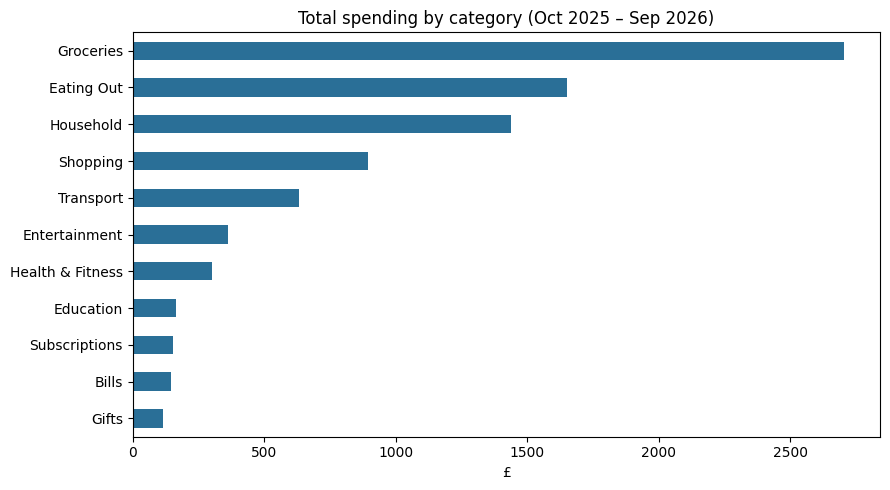

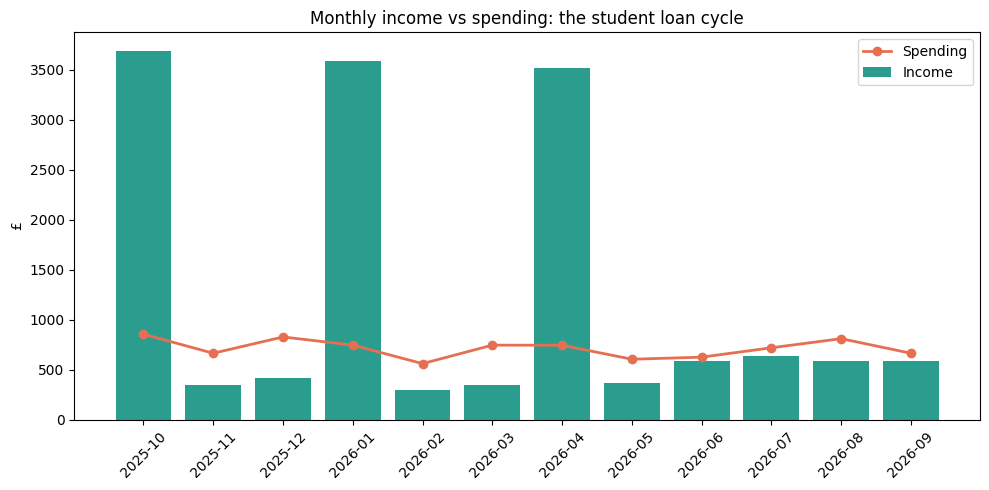

In [5]:
import matplotlib.pyplot as plt

# Chart 1: spending by category
fig, ax = plt.subplots(figsize=(9, 5))
by_cat.sort_values().plot(kind="barh", ax=ax, color="#2a6f97")
ax.set_title("Total spending by category (Oct 2025 – Sep 2026)")
ax.set_xlabel("£")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("spending_by_category.png", dpi=150)
plt.show()

# Chart 2: income vs spending each month
fig, ax = plt.subplots(figsize=(10, 5))
months = monthly.index.astype(str)
ax.bar(months, monthly["Credit"], label="Income", color="#2a9d8f")
ax.plot(months, monthly["Debit"], label="Spending", color="#e76f51",
        marker="o", linewidth=2)
ax.set_title("Monthly income vs spending: the student loan cycle")
ax.set_ylabel("£")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("income_vs_spending.png", dpi=150)
plt.show()